In [2]:
# Reproduce Fig. 1, 2, 3 in "The Impact of Network Structure on Ant Colony Optimization"
# - Fig.1: initial configuration for r=3, t=4 (+ selection probability expressions for ant 5)
# - Fig.2: typical network configuration for r=10, t=300, omega in {-1, -0.9999, 0, 1}
# - Fig.3: m* vs alpha for J=h=0.1 with vertical lines at alpha_s and alpha_c
#
# Requirements: numpy, matplotlib, networkx
# Optional (recommended for Fig.2 layout): graphviz + pygraphviz

import math
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.collections import LineCollection

# Optional layout (more similar to paper's Fig.2)
try:
    from networkx.drawing.nx_agraph import graphviz_layout
    _HAS_GRAPHVIZ_LAYOUT = True
except Exception:
    _HAS_GRAPHVIZ_LAYOUT = False


# -----------------------------
# Network generation (pheromone reference network)
# -----------------------------
def build_pheromone_reference_network(T: int, r: int, omega: float, seed: int = 0) -> nx.DiGraph:
    """
    Build pheromone reference network described in the paper.
    - Nodes: ants 1..T
    - Directed edge i -> t means: ant t referenced ant i (so i's out-degree increases)
    - First r+1 ants form a complete directed graph forward in time:
        for new in 2..r+1, connect all prev < new: prev -> new
    - For new >= r+2:
        choose r distinct previous ants from 1..new-1 with weight max(l(i),0),
        l(i) = r + omega * k_out(i)
      If omega == -1, deterministically choose the previous r ants (extended lattice).
    """
    rng = np.random.default_rng(seed)
    G = nx.DiGraph()
    G.add_nodes_from(range(1, T + 1))

    # initial complete graph among first (r+1) ants (forward edges)
    for new in range(2, r + 2):  # 2..r+1
        for prev in range(1, new):
            G.add_edge(prev, new)

    # growth
    for new in range(r + 2, T + 1):
        t = new - 1  # existing ants: 1..t

        if omega == -1:
            # extended lattice: choose previous r ants deterministically
            chosen = list(range(max(1, t - r + 1), t + 1))[-r:]
        else:
            prev_nodes = np.arange(1, t + 1)
            kout = np.array([G.out_degree(i) for i in prev_nodes], dtype=float)

            l = r + omega * kout
            w = np.maximum(l, 0.0)

            positive = prev_nodes[w > 0]
            w_pos = w[w > 0]

            if len(positive) >= r and w_pos.sum() > 0:
                p = w_pos / w_pos.sum()
                chosen = rng.choice(positive, size=r, replace=False, p=p).tolist()
            else:
                # fallback: take all positive-weight nodes, then fill uniformly from the rest
                chosen = positive.tolist()
                remaining = np.setdiff1d(prev_nodes, positive)
                need = r - len(chosen)
                if need > 0:
                    if len(remaining) >= need:
                        chosen += rng.choice(remaining, size=need, replace=False).tolist()
                    else:
                        # ultimate fallback
                        chosen = prev_nodes[-r:].tolist()

        for i in chosen:
            G.add_edge(i, new)

    return G


# -----------------------------
# Fast-ish drawing helper
# -----------------------------
def draw_graph(ax, G: nx.DiGraph, pos: dict, node_sizes, node_colors,
               edge_alpha=0.15, edge_width=0.25):
    # edges as line segments (no arrows for speed/clarity like the paper)
    segs = [[pos[u], pos[v]] for (u, v) in G.edges()]
    lc = LineCollection(segs, linewidths=edge_width, colors=[(0, 0, 0, edge_alpha)])
    ax.add_collection(lc)

    # nodes
    xy = np.array([pos[n] for n in G.nodes()])
    ax.scatter(
        xy[:, 0], xy[:, 1],
        s=node_sizes,
        c=node_colors,
        cmap="gray", vmin=0, vmax=1,
        linewidths=0
    )
    ax.set_aspect("equal", adjustable="datalim")
    ax.axis("off")


def get_layout(G: nx.DiGraph, seed: int = 0):
    if _HAS_GRAPHVIZ_LAYOUT:
        # "sfdp" tends to resemble the paper-like blobs/bands
        try:
            return graphviz_layout(G, prog="sfdp")
        except Exception:
            pass
    # fallback
    return nx.spring_layout(G, seed=seed, iterations=50)


# -----------------------------
# Fig.1
# -----------------------------
def plot_fig1(output_path="fig1_repro.png"):
    r = 3
    t = 4  # initial config shown in the paper (nodes 1..4)
    omega_symbol = r"\omega"

    # Build the initial complete forward graph among 1..4
    G = nx.DiGraph()
    G.add_nodes_from([1, 2, 3, 4, 5])  # include node 5 as the "next ant"
    for new in range(2, r + 2):  # 2..4
        for prev in range(1, new):
            G.add_edge(prev, new)

    # Positions on a line
    pos = {i: (i, 0.0) for i in [1, 2, 3, 4, 5]}

    fig, ax = plt.subplots(figsize=(9, 2.6))

    # Draw existing complete graph among 1..4 (forward edges)
    segs = [[pos[u], pos[v]] for (u, v) in G.edges() if v <= 4]
    lc = LineCollection(segs, linewidths=1.0, colors=[(0.2, 0.2, 0.2, 0.8)])
    ax.add_collection(lc)

    # Optionally draw faint candidate links to node 5 (illustrative)
    segs2 = [[pos[i], pos[5]] for i in [1, 2, 3, 4]]
    lc2 = LineCollection(segs2, linewidths=0.8, colors=[(0.2, 0.2, 0.2, 0.25)], linestyles="dashed")
    ax.add_collection(lc2)

    # Nodes
    ax.scatter([pos[i][0] for i in [1, 2, 3, 4]], [0, 0, 0, 0], s=800, c=[0.9]*4, cmap="gray", vmin=0, vmax=1)
    ax.scatter([pos[5][0]], [0], s=800, c=[0.9], cmap="gray", vmin=0, vmax=1)

    for i in [1, 2, 3, 4, 5]:
        ax.text(pos[i][0], pos[i][1], str(i), ha="center", va="center", fontsize=12)

    # For r=3 at t=4, out-degrees are: k_out(1)=3, k_out(2)=2, k_out(3)=1, k_out(4)=0
    kout = {1: 3, 2: 2, 3: 1, 4: 0}
    # l(i,4) = r + omega*k_out(i,4)
    # Sum l = (3+3w)+(3+2w)+(3+w)+3 = 12+6w
    # P(Δk_out(i,4)=1) = r*l(i,4)/Sum l
    l_text = {
        1: rf"$3+3{omega_symbol}$",
        2: rf"$3+2{omega_symbol}$",
        3: rf"$3+{omega_symbol}$",
        4: r"$3$",
    }
    p_text = {
        1: rf"$\frac{{3(3+3{omega_symbol})}}{{12+6{omega_symbol}}}$",
        2: rf"$\frac{{3(3+2{omega_symbol})}}{{12+6{omega_symbol}}}$",
        3: rf"$\frac{{3(3+{omega_symbol})}}{{12+6{omega_symbol}}}$",
        4: rf"$\frac{{3\cdot 3}}{{12+6{omega_symbol}}}$",
    }

    for i in [1, 2, 3, 4]:
        ax.text(pos[i][0], -0.45, l_text[i], ha="center", va="top", fontsize=11)
        ax.text(pos[i][0], -0.82, p_text[i], ha="center", va="top", fontsize=11)

    ax.text(1.0, 0.55, r"$r=3$", fontsize=11)
    ax.text(3.2, 0.55, r"$t=4$", fontsize=11)

    ax.set_xlim(0.4, 5.6)
    ax.set_ylim(-1.1, 0.9)
    ax.axis("off")
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.close(fig)
    print(f"[Saved] {output_path}")


# -----------------------------
# Fig.2
# -----------------------------
def plot_fig2(output_path="fig2_repro.png"):
    r = 10
    t = 300  # paper uses t=300
    omegas = [-1.0, -0.9999, 0.0, 1.0]
    labels = [r"$\omega=-1$", r"$\omega=-0.9999$", r"$\omega=0$", r"$\omega=1$"]

    fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(7, 14))

    for ax, omega, lab in zip(axes, omegas, labels):
        G = build_pheromone_reference_network(T=t, r=r, omega=omega, seed=1)
        pos = get_layout(G, seed=1)

        kout = np.array([G.out_degree(n) for n in G.nodes()], dtype=float)

        # Node size ~ out-degree (paper: proportional). Use a slightly nonlinear scaling for visibility.
        node_sizes = 10 + 5 * (kout ** 0.9)

        # Make hubs darker (top 5%), others light gray (to mimic black big hubs in omega=1)
        thr = np.quantile(kout, 0.95)
        node_colors = np.where(kout >= thr, 0.0, 0.7)  # 0=black, 0.7=light gray

        draw_graph(ax, G, pos, node_sizes=node_sizes, node_colors=node_colors,
                   edge_alpha=0.12, edge_width=0.22)
        ax.text(0.02, 0.98, lab, transform=ax.transAxes, ha="left", va="top", fontsize=12)

    fig.tight_layout()
    fig.savefig(output_path, dpi=250)
    plt.close(fig)
    print(f"[Saved] {output_path}")


# -----------------------------
# Fig.3
# -----------------------------
def plot_fig3(output_path="fig3_repro.png"):
    J = 0.1
    h = 0.1

    alpha = np.linspace(0.0, 1.0, 1001)

    # As in the paper (Eq.12):
    alpha_s = (1 - h/2) / (1 + 2*J)
    alpha_c = 1 / (1 + 2*J)

    # m* piecewise (paper's approximation):
    m_star = np.empty_like(alpha)
    denom = 1 - alpha * (1 + 2*J)
    # avoid division by zero in plotting
    eps = 1e-9
    denom_safe = np.where(np.abs(denom) < eps, np.sign(denom) * eps + eps, denom)

    m_lin = (alpha * h) / denom_safe
    m_star = np.where(alpha < alpha_s, m_lin, alpha)

    # dotted stable branches in the figure are m = ±alpha
    fig, ax = plt.subplots(figsize=(6.4, 3.8))
    ax.plot(alpha, m_star, linewidth=2.0)                      # red-ish default color (matplotlib)
    ax.plot(alpha, alpha, linestyle=":", linewidth=1.5)        # +alpha
    ax.plot(alpha, -alpha, linestyle=":", linewidth=1.5)       # -alpha

    ax.axvline(alpha_s, linestyle="--", linewidth=1.2)
    ax.axvline(alpha_c, linestyle="--", linewidth=1.2)

    ax.set_xlim(0, 1)
    ax.set_ylim(-1.05, 1.05)
    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel("m")
    ax.set_title("J=0.1, h=0.1")

    # Small legend-like annotation (similar to paper)
    ax.text(0.02, 0.95,
            r"$m^*$" "\n" r"$m=\alpha$" "\n" r"$m=-\alpha$" "\n" r"$\alpha_s$" "\n" r"$\alpha_c$",
            transform=ax.transAxes, va="top", fontsize=10)

    fig.tight_layout()
    fig.savefig(output_path, dpi=250)
    plt.close(fig)
    print(f"[Saved] {output_path}")
    print(f"alpha_s={alpha_s:.6f}, alpha_c={alpha_c:.6f}")


# -----------------------------
# Run all
# -----------------------------
if __name__ == "__main__":
    plot_fig1("fig1_repro.png")
    plot_fig2("fig2_repro.png")
    plot_fig3("fig3_repro.png")


[Saved] fig1_repro.png
[Saved] fig2_repro.png
[Saved] fig3_repro.png
alpha_s=0.791667, alpha_c=0.833333


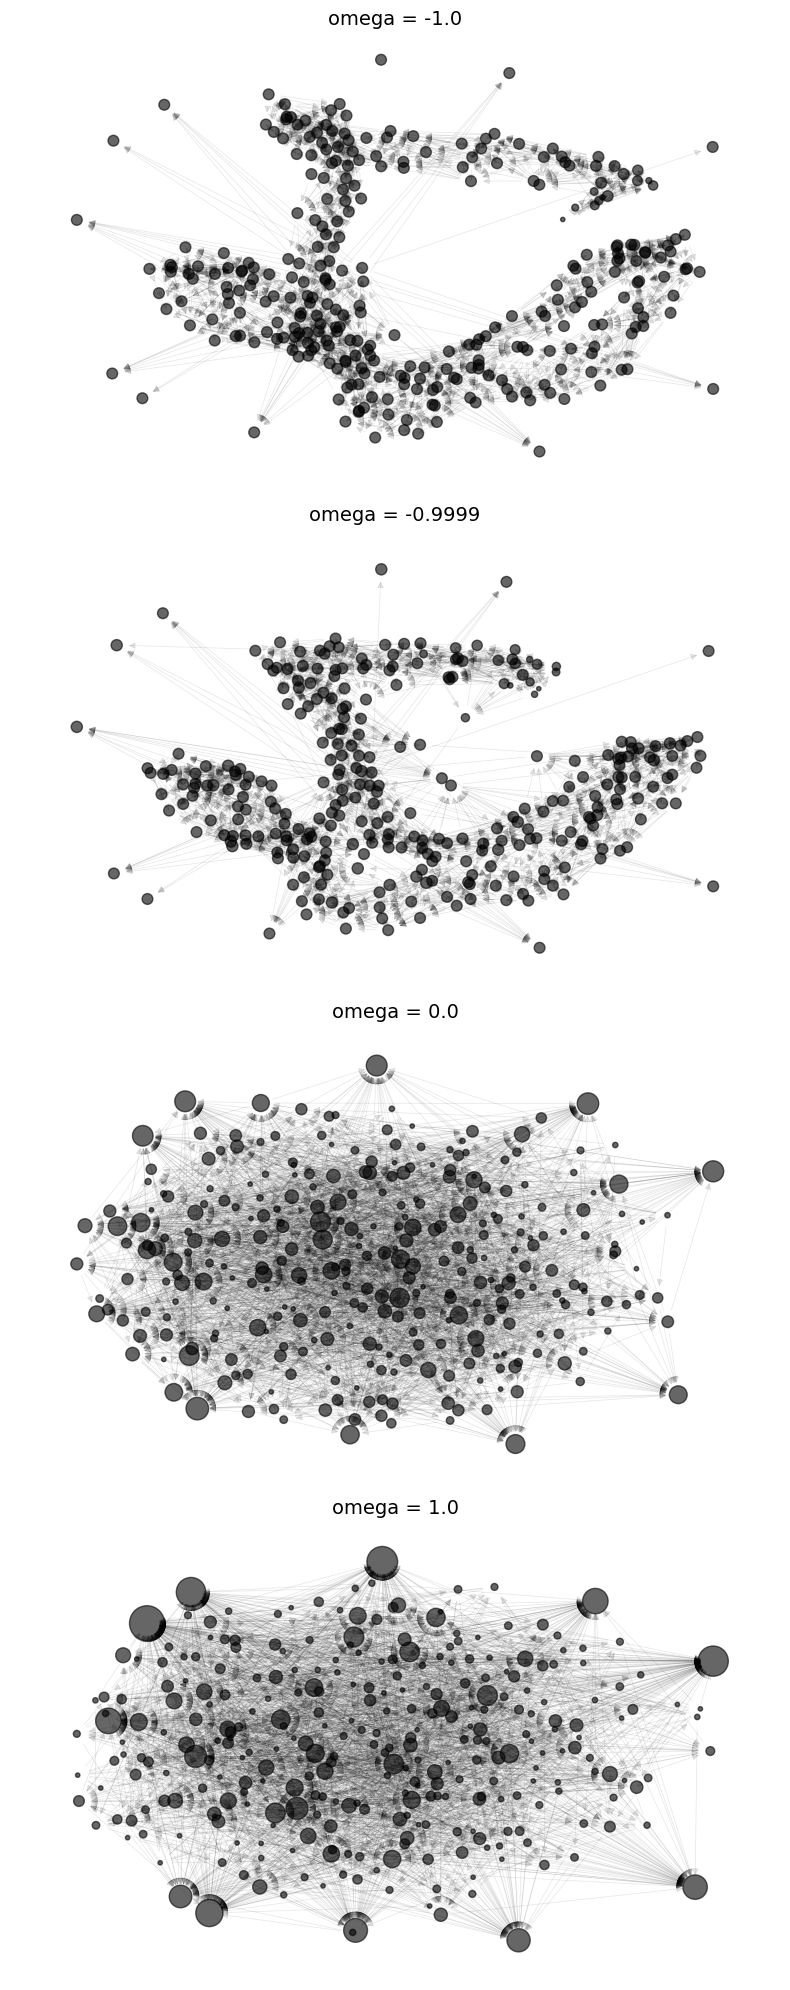

In [3]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def generate_aco_network(omega, r=10, t=300):
    # ネットワーク初期化
    G = nx.DiGraph()
    # 最初のr+1匹は完全グラフ [cite: 76]
    initial_ants = range(1, r + 2)
    G.add_nodes_from(initial_ants)
    
    # 出次数（被選択数）の管理
    # k_out[i] : アリiが「自分より後のアリから」選ばれた回数
    # 初期状態: アリi (i <= r+1) は、自分より後の j (i < j <= r+1) から選ばれている
    k_out = {i: (r + 1) - i for i in initial_ants}
    
    for current_ant in range(r + 2, t + 1):
        G.add_node(current_ant)
        k_out[current_ant] = 0
        
        # 既存のアリのリスト
        existing_ants = list(range(1, current_ant))
        
        # 選択確率の計算 [cite: 79, 92]
        # l(i, t) = r + omega * k_out[i]
        weights = []
        candidates = []
        
        for ant in existing_ants:
            l_val = r + omega * k_out[ant]
            if l_val > 0:
                weights.append(l_val)
                candidates.append(ant)
            else:
                # l < 0 の場合は選ばれない [cite: 86]
                pass
        
        weights = np.array(weights)
        if np.sum(weights) == 0:
            # 万が一すべて0以下になった場合のフォールバック（通常発生しない設定）
            probs = np.ones(len(candidates)) / len(candidates)
        else:
            probs = weights / np.sum(weights)
            
        # r匹を選択
        if len(candidates) >= r:
            chosen_ants = np.random.choice(candidates, size=r, replace=False, p=probs)
        else:
            chosen_ants = candidates # 候補がr未満なら全部選ぶ
            
        # エッジ追加と次数更新
        for target in chosen_ants:
            G.add_edge(current_ant, target) # current -> target (参照)
            k_out[target] += 1
            
    return G, k_out

def plot_fig2():
    omegas = [-1.0, -0.9999, 0.0, 1.0]
    r = 10
    t = 300
    
    fig, axes = plt.subplots(4, 1, figsize=(8, 20))
    
    for ax, omega in zip(axes, omegas):
        np.random.seed(42) # 再現性のためシード固定
        G, k_out = generate_aco_network(omega, r, t)
        
        # ノードサイズを出次数に比例させる [cite: 103]
        # 視認性のため調整
        node_sizes = [10 + 5 * k_out[n] for n in G.nodes()]
        
        # レイアウト決定
        # omegaによってトポロジーが大きく異なるため、layoutアルゴリズムを使い分けるか
        # 論文の図に近いspring_layoutを使用
        if omega <= -0.99:
            # 格子状/スモールワールドはkamada_kawaiなどが綺麗に出やすいが、
            # 図2の"snake"状（1次元的）を再現するにはspring_layoutでiterationsを増やす
            pos = nx.spring_layout(G, k=0.5, iterations=100, seed=42)
        else:
            # ハブ構造が見やすい
            pos = nx.spring_layout(G, k=0.8, seed=42)
            
        ax.set_title(f"omega = {omega}", fontsize=14)
        nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes, node_color='black', alpha=0.6)
        nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.1, width=0.5)
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

plot_fig2()

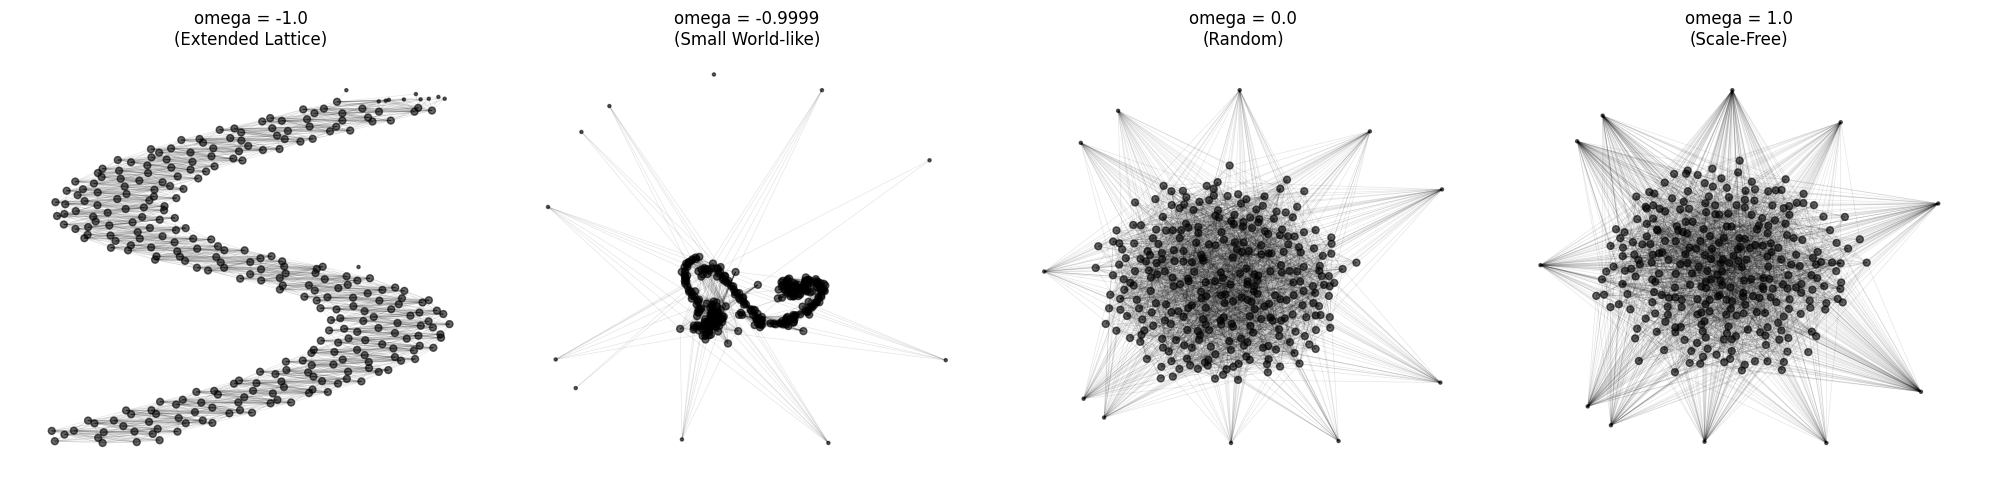

In [8]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def generate_aco_network_refined(omega, r=10, t=300):
    G = nx.DiGraph()
    # 初期ノード (1〜r+1)
    initial_ants = list(range(1, r + 2))
    G.add_nodes_from(initial_ants)
    
    # 次数管理 (論文Eq.1に基づく)
    # 初期状態では、i <= r+1 はそれより後の初期ノードすべてから参照されていると仮定
    k_out = {i: (r + 1) - i for i in initial_ants}
    
    for current_ant in range(r + 2, t + 1):
        G.add_node(current_ant)
        k_out[current_ant] = 0
        
        # 選択候補と重み計算
        existing_ants = np.array(range(1, current_ant))
        # l(i, t) = r + omega * k_out[i]
        # k_outは辞書から取得
        k_vals = np.array([k_out[i] for i in existing_ants])
        l_vals = r + omega * k_vals
        
        # l < 0 は選択不可 (0にする)
        l_vals = np.maximum(l_vals, 0)
        
        if l_vals.sum() == 0:
            # フォールバック（通常は起きない）
            probs = np.ones(len(existing_ants)) / len(existing_ants)
        else:
            probs = l_vals / l_vals.sum()
            
        # 親を選択
        # omega = -1 の場合、理論上は直近 r 匹の重みだけが残り、他は0になるはず
        chosen = np.random.choice(existing_ants, size=r, replace=False, p=probs)
        
        for target in chosen:
            G.add_edge(current_ant, target)
            k_out[target] += 1

    return G

def plot_fig2_corrected():
    # 論文の図2にある代表的なパラメータ
    omegas = [-1.0, -0.9999, 0.0, 1.0]
    r = 10
    t = 300
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    for ax, omega in zip(axes, omegas):
        np.random.seed(123) # 再現性のため固定
        G = generate_aco_network_refined(omega, r, t)
        
        # 次数に応じたノードサイズ
        d = dict(G.out_degree())
        node_sizes = [5 + 2 * d[n] for n in G.nodes()]
        
        # レイアウト調整
        if omega == -1.0:
            # 拡張格子: 本来は1次元的に繋がるため、Kamada-Kawai等の力学モデルで
            # 「長い紐」状になりやすい。あるいはspectral
            pos = nx.kamada_kawai_layout(G)
            title = f"omega = {omega}\n(Extended Lattice)"
        elif omega == -0.9999:
            # スモールワールド的特徴（少し丸まる、またはショートカットがある）
            pos = nx.spring_layout(G, k=0.15, iterations=100, seed=42)
            title = f"omega = {omega}\n(Small World-like)"
        elif omega == 0.0:
            # ランダムグラフ
            pos = nx.spring_layout(G, k=0.5, seed=42)
            title = f"omega = {omega}\n(Random)"
        else:
            # スケールフリー（ハブが存在）
            pos = nx.spring_layout(G, k=0.5, seed=42)
            title = f"omega = {omega}\n(Scale-Free)"
            
        ax.set_title(title)
        nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes, node_color='black', alpha=0.6)
        nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.1, width=0.5, arrows=False)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

plot_fig2_corrected()

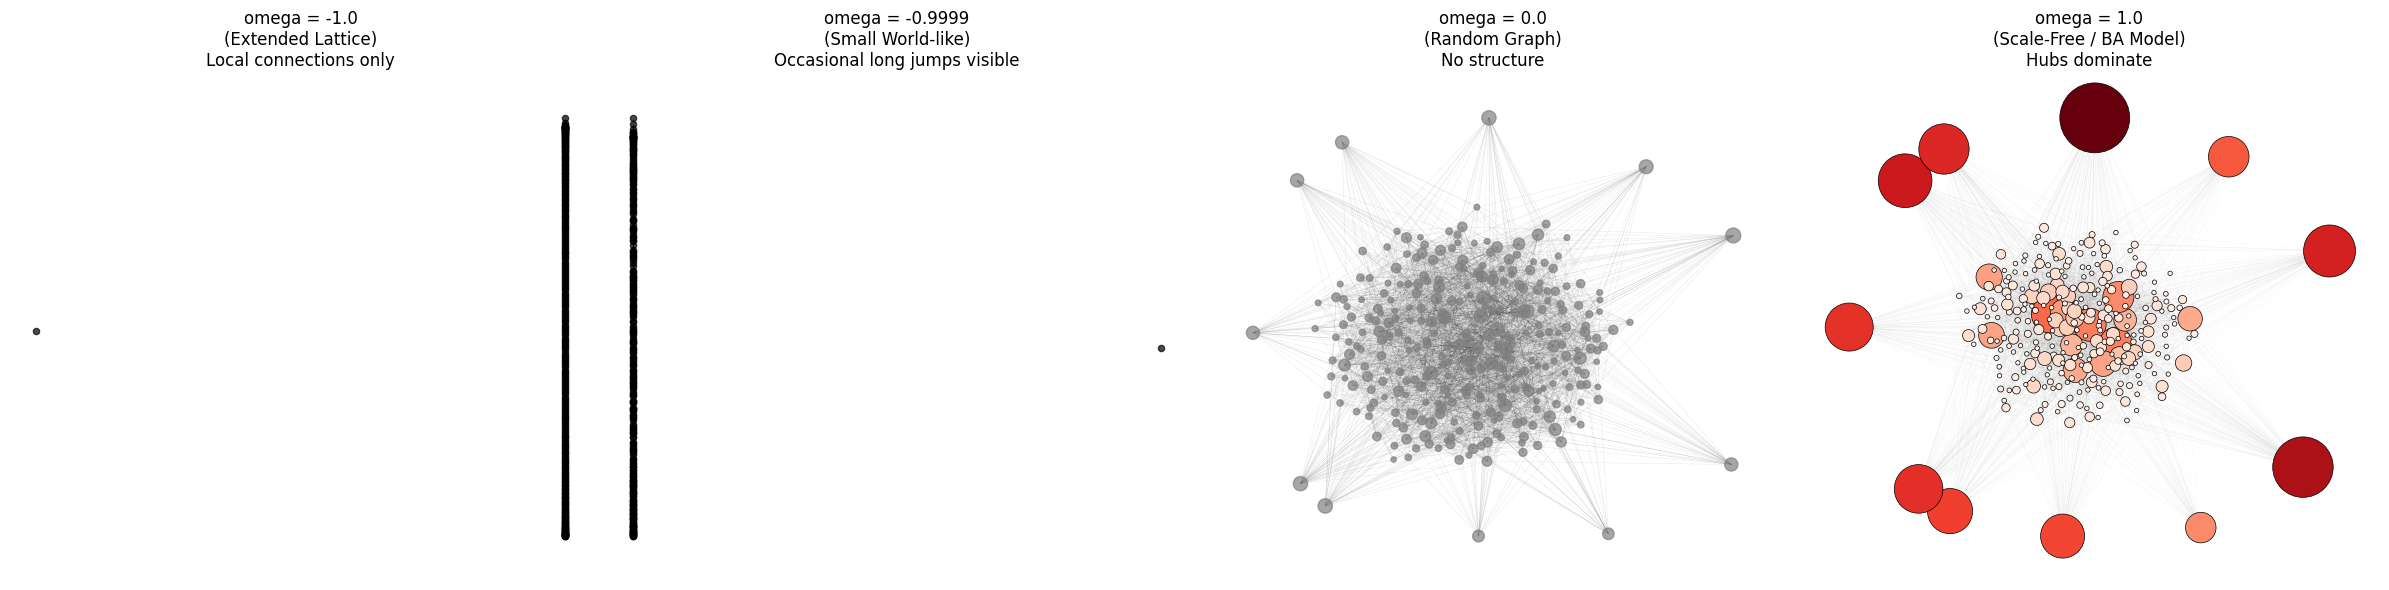

In [10]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def generate_aco_network_refined(omega, r=10, t=300):
    """
    ネットワーク生成ロジックは前回と同様
    """
    G = nx.DiGraph()
    initial_ants = list(range(1, r + 2))
    G.add_nodes_from(initial_ants)
    
    # 次数管理 (論文Eq.1に基づく: 初期は完全グラフ的仮定)
    k_out = {i: (r + 1) - i for i in initial_ants}
    
    for current_ant in range(r + 2, t + 1):
        G.add_node(current_ant)
        k_out[current_ant] = 0
        
        existing_ants = np.array(range(1, current_ant))
        
        # l(i, t) = r + omega * k_out[i]
        k_vals = np.array([k_out[i] for i in existing_ants])
        l_vals = r + omega * k_vals
        l_vals = np.maximum(l_vals, 0)
        
        if l_vals.sum() == 0:
            probs = np.ones(len(existing_ants)) / len(existing_ants)
        else:
            probs = l_vals / l_vals.sum()
            
        # 親を選択
        # replace=Falseで重複なし選択
        if len(existing_ants) >= r:
            chosen = np.random.choice(existing_ants, size=r, replace=False, p=probs)
        else:
            chosen = existing_ants
        
        for target in chosen:
            G.add_edge(current_ant, target)
            k_out[target] += 1

    return G, k_out

def get_snake_layout(G):
    """
    ノードID（時間t）に基づいて、S字（ヘビ型）に配置するレイアウト関数。
    これによりomega=-0.9999でも「基本は格子」であることを強制的に可視化する。
    """
    pos = {}
    nodes = sorted(list(G.nodes()))
    
    # 3列で折り返すようなS字、あるいは正弦波的な配置
    for i, node in enumerate(nodes):
        # x軸は時間進行
        x = i
        # y軸は正弦波でうねらせる（振幅と周期は適当に調整）
        y = np.sin(i / 15.0) * 10
        pos[node] = np.array([x, y])
        
    return pos

def plot_fig2_enhanced():
    omegas = [-1.0, -0.9999, 0.0, 1.0]
    r = 10
    t = 300
    
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    
    # レイアウトのベースとなる「ヘビ型」配置を作成するためのダミー（ID順配置用）
    # 実際には個々のグラフ構造に合わせて微調整する
    
    for ax, omega in zip(axes, omegas):
        np.random.seed(123) # シード固定
        G, k_out_dict = generate_aco_network_refined(omega, r, t)
        
        # 次数リスト取得
        degrees = np.array([val for node, val in k_out_dict.items()])
        
        # --- レイアウトとスタイルの分岐 ---
        
        if omega <= -0.99:
            # === 拡張格子 (-1.0) & スモールワールド (-0.9999) ===
            # 時間発展(ID順)に並べることで、ショートカットを可視化する
            # kamada_kawaiだとショートカットに引っ張られて形が崩れるため、
            # IDに基づいた「Spectral Layout」または自作配置を使うと「飛び」が見やすい
            
            # Spectral Layoutは1次元的な構造をきれいに開く性質がある
            pos = nx.spectral_layout(G)
            
            # ノードサイズ: 一様に見えるように小さめ
            node_sizes = 20
            node_color = 'black'
            alpha_edge = 0.3
            width_edge = 0.5
            
            if omega == -0.9999:
                title = f"omega = {omega}\n(Small World-like)\nOccasional long jumps visible"
            else:
                title = f"omega = {omega}\n(Extended Lattice)\nLocal connections only"

        elif omega == 0.0:
            # === ランダムグラフ ===
            # 全体に広がるSpring Layout
            pos = nx.spring_layout(G, seed=42, k=0.5)
            
            # ノードサイズ: 次数に少し比例させるが、極端な差はない
            node_sizes = [15 + 2 * k_out_dict[n] for n in G.nodes()]
            node_color = 'gray'
            alpha_edge = 0.1
            width_edge = 0.3
            title = f"omega = {omega}\n(Random Graph)\nNo structure"

        else: # omega == 1.0
            # === スケールフリー ===
            # ハブを中心にするため Spring Layout
            pos = nx.spring_layout(G, seed=42, k=0.6, iterations=100)
            
            # 【重要】ハブを強調する
            # サイズを次数の2.5乗などでスケーリングし、格差を強調
            # 最小サイズ10、最大サイズは大きく
            node_sizes = [10 + (k_out_dict[n]**1.8) * 0.5 for n in G.nodes()]
            
            # 色も次数で変える (Redsマップ)
            node_color = degrees
            
            alpha_edge = 0.05 # エッジは薄くして、ノードの集中を見せる
            width_edge = 0.2
            title = f"omega = {omega}\n(Scale-Free / BA Model)\nHubs dominate"

        # --- 描画 ---
        ax.set_title(title, fontsize=12)
        
        # スケールフリーの時はカラーマップを使用
        if omega == 1.0:
            nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes, 
                                   node_color=node_color, cmap=plt.cm.Reds, 
                                   edgecolors='black', linewidths=0.5)
        else:
            nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes, 
                                   node_color=node_color, alpha=0.7)

        # エッジ描画
        # -0.9999の場合、長距離リンクを目立たせる工夫も可能だが、
        # 配置がリニア（Spectral）なら、長い線が自然と目立つ
        nx.draw_networkx_edges(G, pos, ax=ax, alpha=alpha_edge, width=width_edge, arrows=False)
        
        ax.axis('off')

    plt.tight_layout()
    plt.show()

plot_fig2_enhanced()

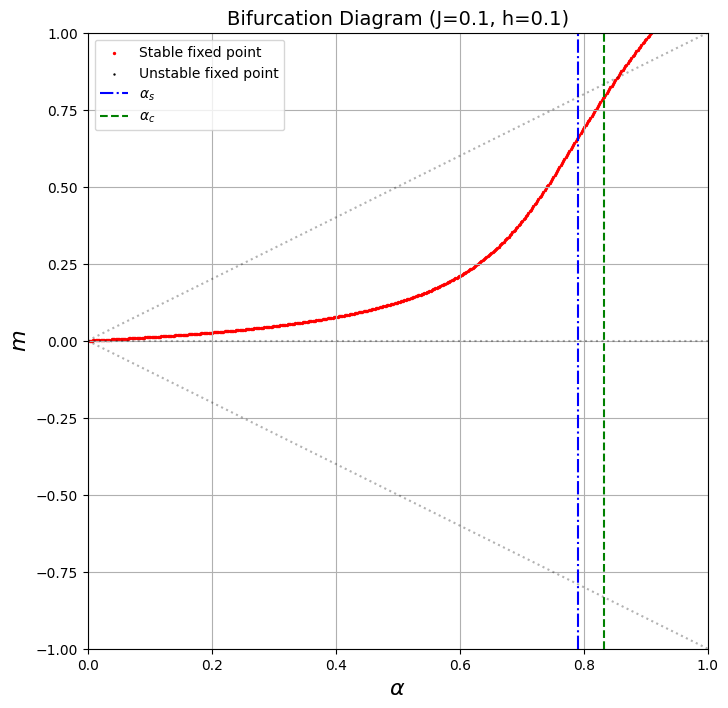

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def get_roots_and_stability(alpha, J, h):
    # 方程式: 2*J*alpha*m^3 + (1 - alpha - 2*J*alpha)*m - alpha*h = 0
    # 係数
    c3 = 2 * J * alpha
    c2 = 0
    c1 = 1 - alpha * (1 + 2 * J)
    c0 = -alpha * h
    
    if abs(c3) < 1e-10: # alpha=0付近
        return []
        
    roots = np.roots([c3, c2, c1, c0])
    # 実数解のみ
    real_roots = [r.real for r in roots if abs(r.imag) < 1e-8]
    real_roots = sorted(list(set(real_roots))) # 重複排除とソート
    
    results = []
    for m in real_roots:
        # 安定性判定: F'(m) < 0 なら安定
        # F'(m) = -(1-alpha) + 2*J*alpha - 6*J*alpha*m^2
        slope = -(1 - alpha) + 2 * J * alpha - 6 * J * alpha * (m**2)
        is_stable = slope < 0
        results.append((m, is_stable))
        
    return results

def plot_fig3_refined():
    J = 0.1
    h = 0.1
    
    # 閾値 [cite: 266, 268]
    alpha_c = 1.0 / (1.0 + 2.0 * J)           # 0.833...
    alpha_s = (1.0 - h / 2.0) / (1.0 + 2.0 * J) # 0.7916...

    alphas = np.linspace(0.001, 0.999, 500)
    
    # プロット用リスト
    stable_m = []
    stable_alpha = []
    unstable_m = []
    unstable_alpha = []
    
    for a in alphas:
        roots_info = get_roots_and_stability(a, J, h)
        for m, is_stable in roots_info:
            if is_stable:
                stable_m.append(m)
                stable_alpha.append(a)
            else:
                unstable_m.append(m)
                unstable_alpha.append(a)
                
    plt.figure(figsize=(8, 8))
    
    # 1. 安定解のプロット（実線・散布図）
    # 視覚的に連続した線に見えるように小さな点、または線で描画
    plt.scatter(stable_alpha, stable_m, s=2, c='red', label='Stable fixed point')
    
    # 2. 不安定解のプロット（点線）
    plt.scatter(unstable_alpha, unstable_m, s=2, c='black', marker='.', label='Unstable fixed point')
    
    # 3. 閾値の垂直線 
    plt.axvline(x=alpha_s, color='blue', linestyle='-.', label=r'$\alpha_s$')
    plt.axvline(x=alpha_c, color='green', linestyle='--', label=r'$\alpha_c$')
    
    # 4. ガイドライン (y=x, y=-x, y=0)
    plt.plot([0, 1], [0, 1], 'k:', alpha=0.3)
    plt.plot([0, 1], [0, -1], 'k:', alpha=0.3)
    plt.axhline(y=0, color='k', linestyle=':', alpha=0.3)

    # 軸ラベルと範囲
    plt.xlabel(r'$\alpha$', fontsize=16)
    plt.ylabel(r'$m$', fontsize=16)
    plt.title(f'Bifurcation Diagram (J={J}, h={h})', fontsize=14)
    plt.xlim(0, 1.0)
    plt.ylim(-1.0, 1.0)
    plt.legend()
    plt.grid(True)
    
    plt.show()

plot_fig3_refined()

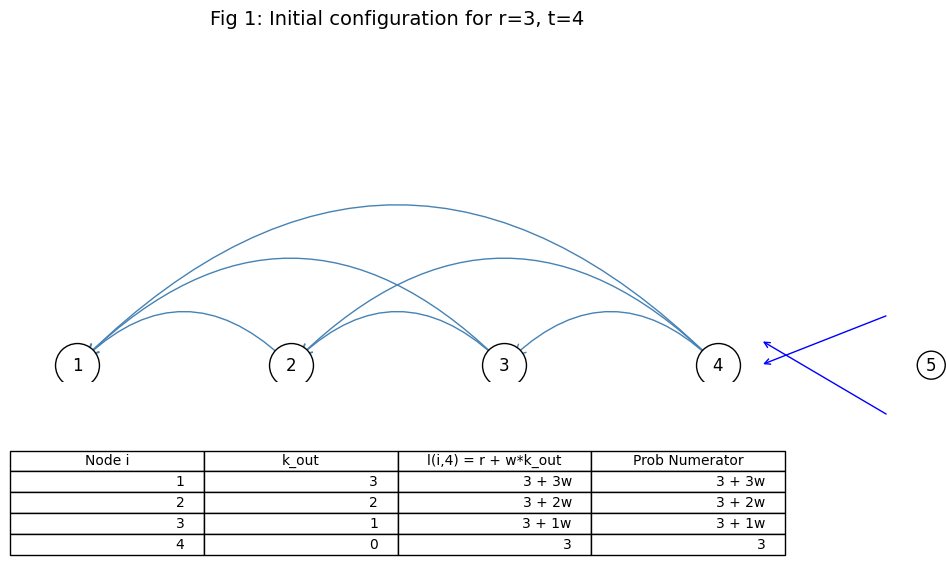

In [6]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

def reproduce_fig1():
    # パラメータ設定 [cite: 67, 75]
    r = 3
    t = 4
    
    # グラフの構築 (t=4までの完全グラフ) [cite: 76]
    G = nx.DiGraph()
    nodes = list(range(1, t + 1))
    G.add_nodes_from(nodes)
    
    # 完全グラフの構築 (すべてのノードが互いに接続)
    # 論文の図では1->2, 1->3, 1->4...のように描かれていますが
    # 「The first r+1 ants... construct the complete graph」に基づき全結合します
    for i in nodes:
        for j in nodes:
            if i != j:
                G.add_edge(j, i) # 矢印の向きは参照関係(後→前)

    # 描画設定
    plt.figure(figsize=(10, 6))
    
    # ノードの配置 (一直線)
    pos = {i: (i, 0) for i in nodes}
    # 次に来るノード5 (イメージ)
    pos[5] = (5, 0)
    
    # 描画
    ax = plt.gca()
    nx.draw_networkx_nodes(G, pos, node_size=1000, node_color='white', edgecolors='black')
    nx.draw_networkx_labels(G, pos)
    
    # 既存エッジの描画（論文の図のようにカーブさせる）
    # 実際には完全グラフですが、図1の見た目に寄せて主要なリンクを描画
    edges = [(2,1), (3,2), (4,3), (3,1), (4,2), (4,1)] 
    nx.draw_networkx_edges(G, pos, edgelist=edges, connectionstyle="arc3,rad=0.5", arrowstyle='->', arrowsize=20, edge_color='steelblue')

    # ノード5への矢印（イメージ）
    ax.annotate("", xy=(4.2, 0), xytext=(4.8, 0.2), arrowprops=dict(arrowstyle="->", color="blue"))
    ax.annotate("", xy=(4.2, -0.1), xytext=(4.8, 0.0), arrowprops=dict(arrowstyle="->", color="blue"))
    ax.annotate("", xy=(4.2, 0.1), xytext=(4.8, -0.2), arrowprops=dict(arrowstyle="->", color="blue"))
    
    plt.text(5, 0, "5", fontsize=12, ha='center', va='center', bbox=dict(facecolor='white', edgecolor='black', boxstyle='circle'))

    # --- 下部の表の計算と表示 ---
    # k_outの計算 (初期完全グラフにおいて、各ノードは自分より後のノードから選ばれている)
    # ノード1は2,3,4から選ばれた -> k_out=3
    # ノード2は3,4から選ばれた -> k_out=2
    # ノード3は4から選ばれた -> k_out=1
    # ノード4はまだ誰からも選ばれていない -> k_out=0
    # ※論文[cite: 82] C_out(i, r+1) = r+1-i (for i <= r+1) と一致
    k_outs = {1: 3, 2: 2, 3: 1, 4: 0}
    
    # 表データの作成
    columns = ["Node i", "k_out", "l(i,4) = r + w*k_out", "Prob Numerator"]
    cell_text = []
    
    # 論文中の式と値を再現 [cite: 73]
    for i in [1, 2, 3, 4]:
        k = k_outs[i]
        l_expr = f"3 + {k}w" if k > 0 else "3" # wはomega
        prob_expr = l_expr
        cell_text.append([f"{i}", f"{k}", l_expr, prob_expr])

    # 表の描画
    table = plt.table(cellText=cell_text, colLabels=columns, loc='bottom', bbox=[0.0, -0.5, 1.0, 0.3])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    
    plt.title(f"Fig 1: Initial configuration for r={r}, t={t}", fontsize=14)
    plt.axis('off')
    plt.subplots_adjust(bottom=0.3)
    plt.show()

reproduce_fig1()